<class 'pandas.core.frame.DataFrame'>
Index: 505 entries, 1 to 567
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region           505 non-null    object 
 1   year             505 non-null    int64  
 2   population       505 non-null    float64
 3   region_standard  505 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 19.7+ KB
None

Missing values by column:
 region             0
year               0
population         0
region_standard    0
dtype: int64

Number of unique regions: 83
Number of unique years: 6

Population statistics:
 count    5.050000e+02
mean     1.760602e+06
std      1.591117e+06
min      4.089600e+04
25%      8.583120e+05
50%      1.274503e+06
75%      2.552298e+06
max      1.072643e+07
Name: population, dtype: float64


/var/folders/m5/5wwwb0bj5jddhlnkw6777l600000gn/T/ipykernel_7280/1716993273.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


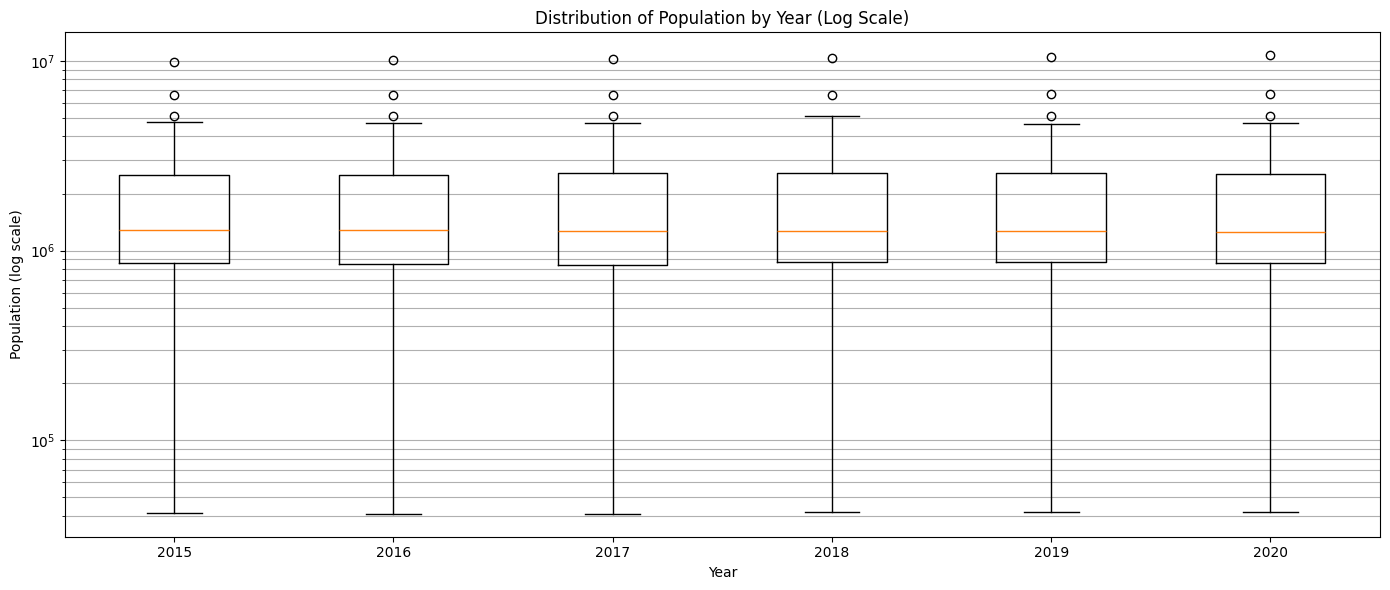

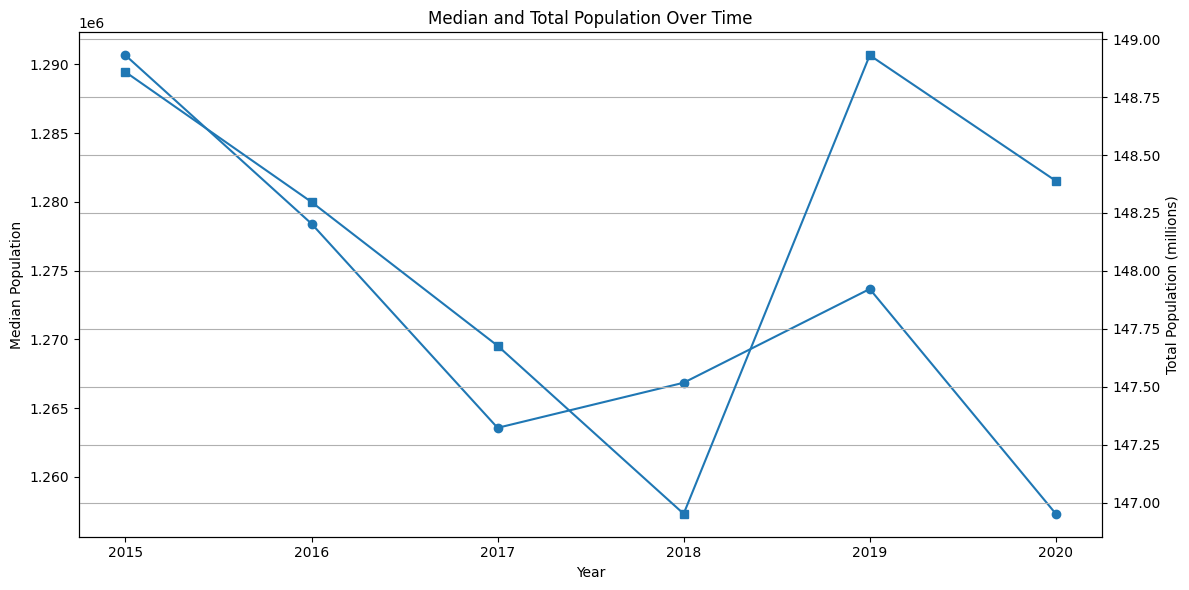

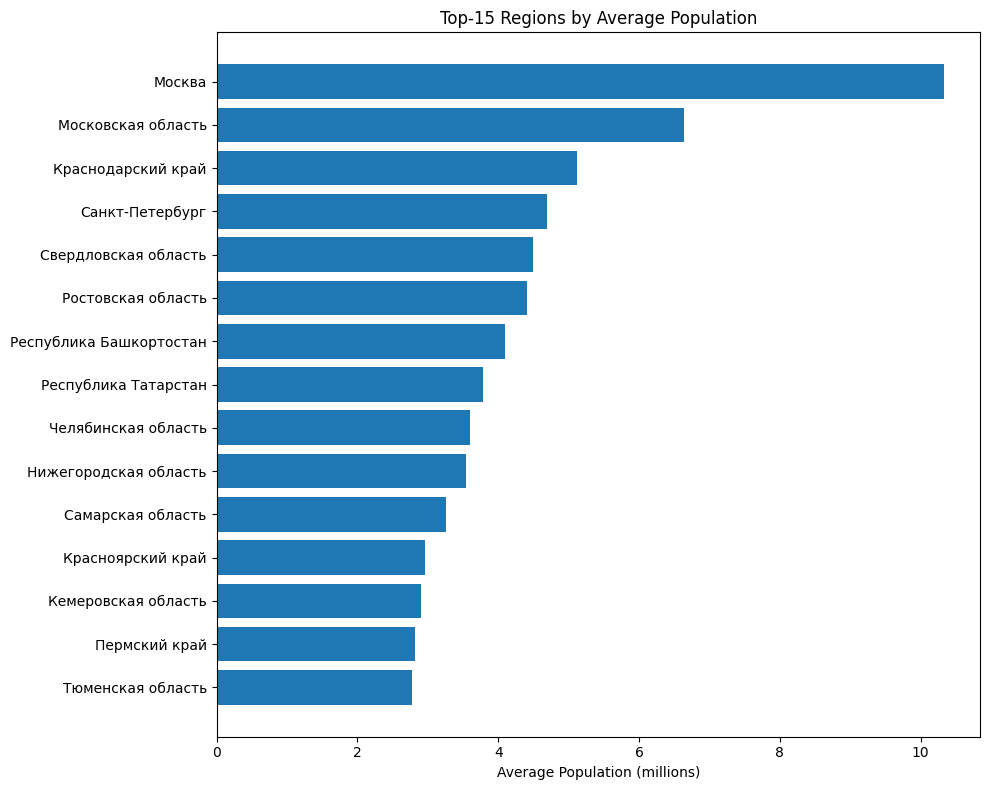

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load data
file_path = "../../outputs/standardized_datasets/population_standardized.csv"
df = pd.read_csv(file_path)

# 2. Keep only rows with standardized region names
df = df[df["region_standard"].notna()].copy()

# 3. Check data types and missing values
print(df.info())
print("\nMissing values by column:\n", df.isnull().sum())

# 4. Number of unique regions and years
print("\nNumber of unique regions:", df["region_standard"].nunique())
print("Number of unique years:", df["year"].nunique())

# 5. Summary statistics
print("\nPopulation statistics:\n", df["population"].describe())

# 6. Median and total population trends
median_population_by_year = df.groupby("year")["population"].median()
total_population_by_year = df.groupby("year")["population"].sum()

# 7. Boxplot with log scale
plt.figure(figsize=(14,6))
plt.boxplot(
    [df[df["year"] == year]["population"] for year in sorted(df["year"].unique())],
    labels=sorted(df["year"].unique())
)
plt.yscale("log")
plt.title("Distribution of Population by Year (Log Scale)")
plt.ylabel("Population (log scale)")
plt.xlabel("Year")
plt.grid(True, which="both", axis="y")
plt.tight_layout()
plt.show()

# 8. Median and total trends (dual axis)
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.set_xlabel("Year")
ax1.set_ylabel("Median Population")
ax1.plot(median_population_by_year.index, median_population_by_year.values, marker="o", label="Median")

ax2 = ax1.twinx()
ax2.set_ylabel("Total Population (millions)")
ax2.plot(total_population_by_year.index, total_population_by_year.values / 1e6, marker="s", label="Total")

plt.title("Median and Total Population Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()

# 9. Top-15 regions by average population
top15_regions = (
    df.groupby("region_standard")["population"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,8))
plt.barh(top15_regions.index, top15_regions.values / 1e6)
plt.xlabel("Average Population (millions)")
plt.title("Top-15 Regions by Average Population")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# EDA of `population_standardized.csv`

## Data Description
- The dataset contains 505 observations across 83 regions.
- Time coverage: 2015–2020.
- Key variable: total population.

---

## Data Types
- All variables are correctly formatted:
  - `year`: int64  
  - `population`: float64  
  - `region_standard`: object  

---

## Missing Values
- No missing values remain after filtering.

---

## Duplicates
- No duplicate records were found.

---

## Summary Statistics
- Mean population: ~1,760,600  
- Median: ~1,274,500  
- Maximum: ~10,726,000 (Moscow)  
- 75% of regions have fewer than ~2,552,000 people  
- Minimum: ~40,896  

The gap between mean and median reflects a right-skewed distribution driven by a small number of highly populated regions.

---

## Trends Over Time
- Median regional population remains relatively stable over time.  
- Total population across all regions shows a slight increase.  
- Moscow consistently remains the largest region by population.  

---

## Distribution Patterns
- The log-scale boxplot highlights strong differences between small and large regions.  
- Most regions have populations below ~2 million, while a few large regions dominate the upper tail.  

---

## Top-15 Regions by Average Population
The largest regions include:

- Moscow  
- Moscow Oblast  
- Krasnodar Krai  
- Republic of Bashkortostan  
- Saint Petersburg  
- Rostov Oblast  
- Chelyabinsk Oblast  
- Sverdlovsk Oblast  
- Republic of Tatarstan  
- Samara Oblast  
- Nizhny Novgorod Oblast  
- Republic of Dagestan  
- Khanty-Mansi Autonomous Okrug  
- Stavropol Krai  
- Perm Krai  

---

## Outliers
- Extremely high values correspond to Moscow and the Moscow region.  
- These observations are retained, as they reflect real population concentration rather than data errors.  

---

## Interpretation
- Population is highly unevenly distributed across regions, creating strong scale differences.  
- Large regions may dominate aggregate indicators (e.g., total production or total cases), while smaller regions may appear less influential in absolute terms.  
- This reinforces the importance of using per-capita indicators when comparing regions.  

Population primarily captures **scale**, while other variables (income, poverty, health) capture **structure**.

---

## Conclusion
The dataset is clean and suitable for further analysis.

Population provides essential context for interpreting regional indicators and helps ensure that clustering reflects structural differences rather than simple size effects.

In [2]:
df.to_csv("../../data/clean/population_AfterEDA.csv", index=False)